In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
# Education 1 'Below College' 2 'College' 3 'Bachelor' 4 'Master' 5 'Doctor'
# JobSatisfaction
# 1 'Low' 2 'Medium' 3 'High' 4 'Very High'
# PerformanceRating
# 1 'Low' 2 'Good' 3 'Excellent' 4 'Outstanding'
# WorkLifeBalance
# 1 'Bad' 2 'Good' 3 'Better' 4 'Best'

In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

## Drop Unnecessary Columns



In [3]:
df.drop(columns = ['EmployeeNumber','HourlyRate','MonthlyRate','Over18','DailyRate','EnvironmentSatisfaction','JobInvolvement','RelationshipSatisfaction','StockOptionLevel','StandardHours','YearsSinceLastPromotion','YearsWithCurrManager'],inplace=True)

In [4]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeCount', 'Gender', 'JobLevel',
       'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    1470 non-null   int64 
 1   Attrition              1470 non-null   object
 2   BusinessTravel         1470 non-null   object
 3   Department             1470 non-null   object
 4   DistanceFromHome       1470 non-null   int64 
 5   Education              1470 non-null   int64 
 6   EducationField         1470 non-null   object
 7   EmployeeCount          1470 non-null   int64 
 8   Gender                 1470 non-null   object
 9   JobLevel               1470 non-null   int64 
 10  JobRole                1470 non-null   object
 11  JobSatisfaction        1470 non-null   int64 
 12  MaritalStatus          1470 non-null   object
 13  MonthlyIncome          1470 non-null   int64 
 14  NumCompaniesWorked     1470 non-null   int64 
 15  OverTime             

In [ ]:
df.describe()

,Age,DistanceFromHome,Education,EmployeeCount,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole
count,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,1.0,2.063946,2.728571,6502.931293,2.693197,15.209524,3.153741,11.279592,2.799320,2.761224,7.008163,4.229252
std,9.135373,8.106864,1.024165,0.0,1.106940,1.102846,4707.956783,2.498009,3.659938,0.360824,7.780782,1.289271,0.706476,6.126525,3.623137
min,18.000000,1.000000,1.000000,1.0,1.000000,1.000000,1009.000000,0.000000,11.000000,3.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,1.0,1.000000,2.000000,2911.000000,1.000000,12.000000,3.000000,6.000000,2.000000,2.000000,3.000000,2.000000
50%,36.000000,7.000000,3.000000,1.0,2.000000,3.000000,4919.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000
75%,43.000000,14.000000,4.000000,1.0,3.000000,4.000000,8379.000000,4.000000,18.000000,3.000000,15.000000,3.000000,3.000000,9.000000,7.000000
max,60.000000,29.000000,5.000000,1.0,5.000000,4.000000,19999.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000


In [ ]:
# create mapping dictionary
education_map = {
    1: "Below College",
    2: "College",
    3: "Bachelor",
    4: "Master",
    5: "Doctor"
}

# convert numeric to string
df["Education_Level"] = df["Education"].map(education_map)

In [ ]:
df[['Education','Education_Level']]

,Education,Education_Level
0,2,College
1,1,Below College
2,2,College
3,4,Master
4,1,Below College
...,...,...
1465,2,College
1466,1,Below College
1467,3,Bachelor
1468,3,Bachelor


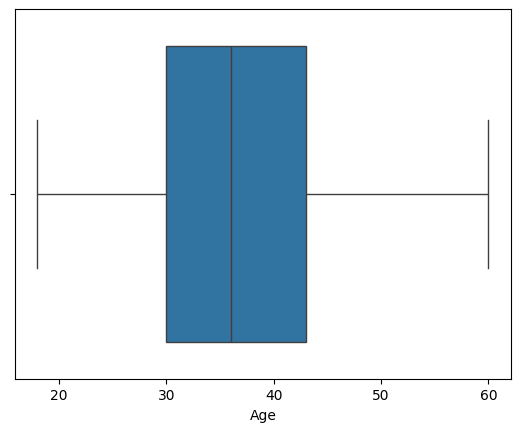

In [ ]:
sns.boxplot(data = df, x = "Age")
plt.show()

<Axes: xlabel='MonthlyIncome'>

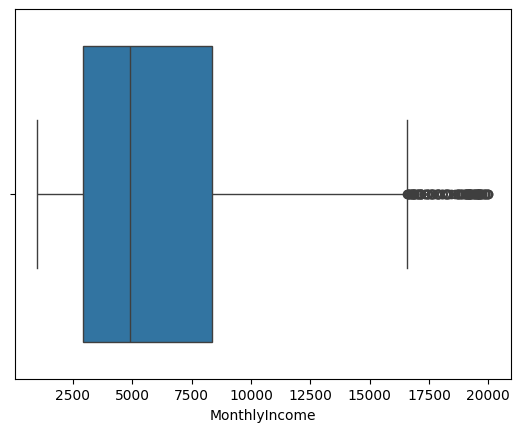

In [ ]:
sns.boxplot(x='MonthlyIncome',data=df)

In [ ]:
df['Age'].mean()

np.float64(36.923809523809524)

In [ ]:
df['Age'].min()

18

##Calculate Attrition Rate

In [ ]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [ ]:
df["Attrition"].value_counts(normalize=True) * 100

,proportion
Attrition,
No,83.877551
Yes,16.122449


In [9]:
df["Attrition_num"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

In [10]:
df[['Attrition','Attrition_num']]

,Attrition,Attrition_num
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0
...,...,...
1465,No,0
1466,No,0
1467,No,0
1468,No,0


In [11]:
df.groupby("Department")['Attrition_num'].sum()

,Attrition_num
Department,
Human Resources,12
Research & Development,133
Sales,92


In [ ]:
df['Attrition_num'].mean() * 100

np.float64(16.122448979591837)

In [ ]:
pd.crosstab(df['Department'],df['Attrition'])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [ ]:
pd.crosstab(df['JobRole'],df['Attrition'],margins=True)

Attrition,No,Yes,All
JobRole,,,
Healthcare Representative,122,9,131
Human Resources,40,12,52
Laboratory Technician,197,62,259
Manager,97,5,102
Manufacturing Director,135,10,145
Research Director,78,2,80
Research Scientist,245,47,292
Sales Executive,269,57,326
Sales Representative,50,33,83


In [ ]:
df.pivot_table(index='OverTime', columns='Attrition', aggfunc='size', fill_value=0)

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [ ]:
df.groupby("OverTime")['EmployeeCount'].count()

,EmployeeCount
OverTime,
No,1054
Yes,416


In [ ]:
df['Attrition'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df.corr(numeric_only=True)

,Age,DistanceFromHome,Education,EmployeeCount,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,Attrition_num
Age,1.000000,-0.001686,0.208034,NaN,0.509604,-0.004892,0.497855,0.299635,0.003634,0.001904,0.680381,-0.019621,-0.021490,0.311309,0.212901,-0.159205
DistanceFromHome,-0.001686,1.000000,0.021042,NaN,0.005303,-0.003669,-0.017014,-0.029251,0.040235,0.027110,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.077924
Education,0.208034,0.021042,1.000000,NaN,0.101589,-0.011296,0.094961,0.126317,-0.011111,-0.024539,0.148280,-0.025100,0.009819,0.069114,0.060236,-0.031373
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
JobLevel,0.509604,0.005303,0.101589,NaN,1.000000,-0.001944,0.950300,0.142501,-0.034730,-0.021222,0.782208,-0.018191,0.037818,0.534739,0.389447,-0.169105
JobSatisfaction,-0.004892,-0.003669,-0.011296,NaN,-0.001944,1.000000,-0.007157,-0.055699,0.020002,0.002297,-0.020185,-0.005779,-0.019459,-0.003803,-0.002305,-0.103481
MonthlyIncome,0.497855,-0.017014,0.094961,NaN,0.950300,-0.007157,1.000000,0.149515,-0.027269,-0.017120,0.772893,-0.021736,0.030683,0.514285,0.363818,-0.159840
NumCompaniesWorked,0.299635,-0.029251,0.126317,NaN,0.142501,-0.055699,0.149515,1.000000,-0.010238,-0.014095,0.237639,-0.066054,-0.008366,-0.118421,-0.090754,0.043494
PercentSalaryHike,0.003634,0.040235,-0.011111,NaN,-0.034730,0.020002,-0.027269,-0.010238,1.000000,0.773550,-0.020608,-0.005221,-0.003280,-0.035991,-0.001520,-0.013478
PerformanceRating,0.001904,0.027110,-0.024539,NaN,-0.021222,0.002297,-0.017120,-0.014095,0.773550,1.000000,0.006744,-0.015579,0.002572,0.003435,0.034986,0.002889


In [ ]:
pd.crosstab(df["JobSatisfaction"], df["Attrition"], normalize="index") * 100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


In [ ]:
df.groupby("Attrition")["YearsAtCompany"].mean()

,YearsAtCompany
Attrition,
No,7.369019
Yes,5.130802


In [ ]:
df.groupby("TotalWorkingYears")["MonthlyIncome"].mean()

,MonthlyIncome
TotalWorkingYears,
0,1523.636364
1,2208.827160
2,2650.193548
3,2781.047619
4,3614.428571
5,3476.659091
6,4215.256000
7,4171.308642
8,4209.252427


In [ ]:
pd.crosstab(df["Gender"], df["Attrition"])

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


In [ ]:
pd.crosstab(df["MaritalStatus"], df["Attrition"], normalize="index") * 100

Attrition,No,Yes
MaritalStatus,,
Divorced,89.908257,10.091743
Married,87.518574,12.481426
Single,74.468085,25.531915


In [ ]:
df.pivot_table(index='JobRole',columns=['Gender','MaritalStatus'],values='MonthlyIncome',aggfunc='mean',
    fill_value=0)

Gender                           Female                              \
MaritalStatus                  Divorced       Married        Single   
JobRole                                                               
Healthcare Representative   7038.700000   7299.916667   7855.235294   
Human Resources             4516.500000   4278.875000   5088.500000   
Laboratory Technician       2962.529412   3558.000000   3014.000000   
Manager                    17021.300000  16892.964286  16866.888889   
Manufacturing Director      6347.277778   7819.906250   7680.545455   
Research Director          16706.000000  14583.125000  14949.600000   
Research Scientist          3382.434783   3477.711111   3195.152174   
Sales Executive             6984.652174   6708.134328   6733.261905   
Sales Representative        2669.200000   2825.071429   2559.842105   

Gender                             Male                              
MaritalStatus                  Divorced       Married        Single  
JobRole                                                              
Healthcare Representative   7878.333333   7578.918919   7244.421053  
Human Resources             3077.100000   4618.000000   4079.500000  
Laboratory Technician       3286.184211   3229.397436   3201.241379  
Manager                    16813.615385  17660.785714  17459.571429  
Manufacturing Director      7222.222222   6883.028571   7671.450000  
Research Director          16280.750000  16767.772727  17059.222222  
Research Scientist          3296.615385   3194.584416   3068.564516  
Sales Executive             7142.000000   7141.714286   6812.343750  
Sales Representative        2701.666667   2529.300000   2612.000000

In [ ]:
pd.crosstab(df["JobRole"], df["Attrition"], margins=True)

Attrition,No,Yes,All
JobRole,,,
Healthcare Representative,122,9,131
Human Resources,40,12,52
Laboratory Technician,197,62,259
Manager,97,5,102
Manufacturing Director,135,10,145
Research Director,78,2,80
Research Scientist,245,47,292
Sales Executive,269,57,326
Sales Representative,50,33,83


In [ ]:
df.groupby("Education_Level")['EmployeeCount'].count().sort_values(ascending= False ).reset_index()

,Education_Level,EmployeeCount
0,Bachelor,572
1,Master,398
2,College,282
3,Below College,170
4,Doctor,48


<Axes: xlabel='EducationField'>

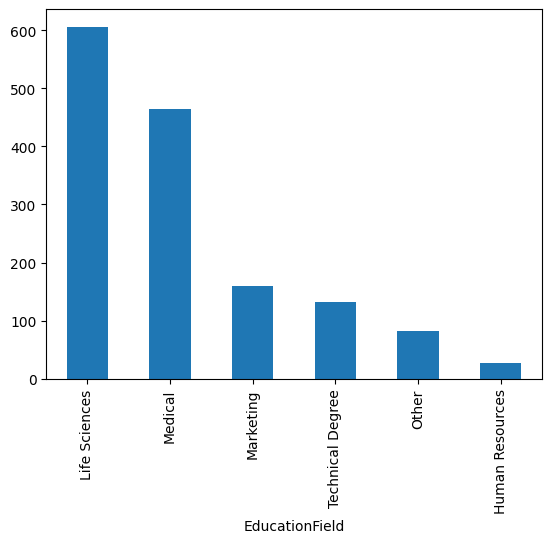

In [ ]:
df['EducationField'].value_counts().plot(kind="bar")

In [5]:
df.to_csv("HR-Attrition-Cleaned.csv",index=False)